<a href="https://colab.research.google.com/github/ThaisEDomingues/healthcare/blob/main/ETL_Healthcare.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#ETL - Extrair, transformar e carregar

In [21]:
#importando um repositorio do github
!git clone https://github.com/ChiaviniK/healthcare




fatal: destination path 'healthcare' already exists and is not an empty directory.


In [22]:
import pandas as pd
df_healthcare = pd.read_csv('/content/healthcare/healthcare_dataset.csv')

print('informações base do csv')

df_healthcare.info()
display(df_healthcare .head(5))



informações base do csv
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55500 entries, 0 to 55499
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Name                55500 non-null  object 
 1   Age                 55500 non-null  int64  
 2   Gender              55500 non-null  object 
 3   Blood Type          55500 non-null  object 
 4   Medical Condition   55500 non-null  object 
 5   Date of Admission   55500 non-null  object 
 6   Doctor              55500 non-null  object 
 7   Hospital            55500 non-null  object 
 8   Insurance Provider  55500 non-null  object 
 9   Billing Amount      55500 non-null  float64
 10  Room Number         55500 non-null  int64  
 11  Admission Type      55500 non-null  object 
 12  Discharge Date      55500 non-null  object 
 13  Medication          55500 non-null  object 
 14  Test Results        55500 non-null  object 
dtypes: float64(1), int64(2), obje

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Bobby JacksOn,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal
1,LesLie TErRy,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive
2,DaNnY sMitH,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal
3,andrEw waTtS,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,Abnormal
4,adrIENNE bEll,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal


In [23]:
#Transformando os dados
#Padronização dos campos
#arrumar data de objeto para tipo de dado data
#arrumar account para duas casas decimais

#Padronização dos campos - title é deixar sempre a primeira letra maiuscula
df_healthcare['Name'] = df_healthcare['Name'].str.title()
df_healthcare['Date of Admission']  = pd.to_datetime(df_healthcare['Date of Admission'])
df_healthcare['Discharge Date']  = pd.to_datetime(df_healthcare['Discharge Date'] )

df_healthcare['Days Hospitalized'] = (df_healthcare['Discharge Date'] - df_healthcare['Date of Admission']).dt.days

#arredondadno os valores
df_healthcare['Billing Amount'] = df_healthcare['Billing Amount'].round(2)

df_healthcare = df_healthcare.drop_duplicates()





In [24]:
from numpy import False_
#load - carregar dados

df_healthcare.to_csv('healthcare_clean.csv', index=False)



In [ ]:
#dados estatisticos do arquivo

display(df_healthcare.describe().round(2))
print('estatistica por categoria')
display(df_healthcare.describe(include=['O', 'object']))

print('estatistica por categoria')
display(df_healthcare['Medical Condition'].value_counts())
print('estatistica por tipo sanguineo')
display(df_healthcare['Blood Type'].value_counts())




<Axes: xlabel='Medical Condition', ylabel='count'>

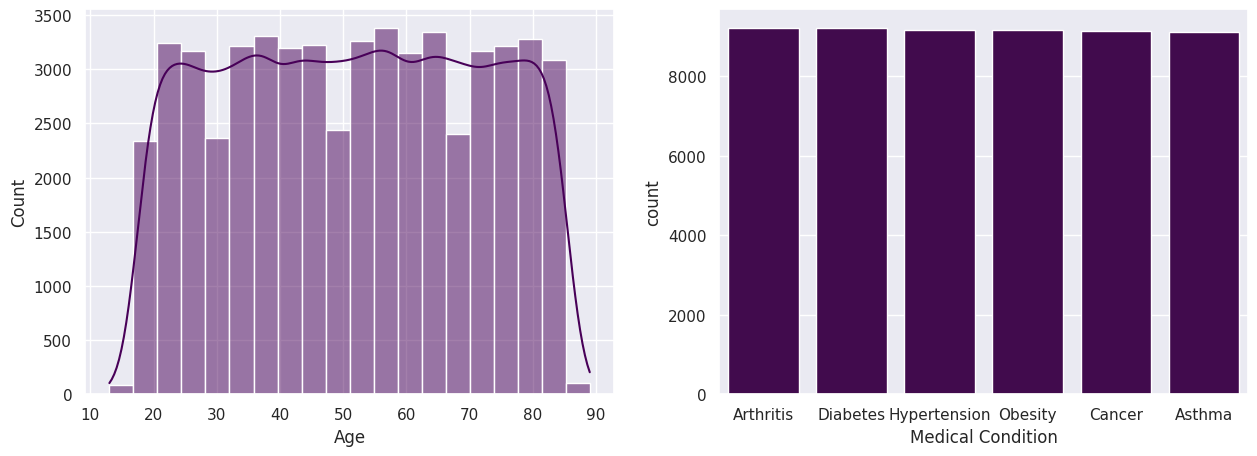

In [34]:
#graficos

import matplotlib.pyplot as plt
import seaborn as sns

#configura o estilo dos graficos
sns.set_theme(style= 'darkgrid')
plt.figure(figsize=(15,5))

#podemos criar subplot

plt.subplot(1,2,1)
sns.histplot(df_healthcare['Age'], bins=20, kde=True, color='#480058')
plt.subplot(1,2,2)
sns.countplot(data=df_healthcare, x='Medical Condition',
              order= df_healthcare['Medical Condition'].value_counts().index,
              color='#480058')



